<a href="https://colab.research.google.com/github/AdrionRosanelli/LoRa_Sionna/blob/main/Lora_Phy_Tx_Block.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LoRa PHY Transmitter — Sionna Block Implementation**

Implementation of the LoRa Physical Layer Transmitter using the Sionna `Block` structure.

This notebook covers:
- Chirp generation and CSS (Chirp Spread Spectrum) modulation
- Payload encoding: whitening, header generation, CRC, Hamming coding, and interleaving
- LoRa packet assembly (preamble, sync word, down-chirps, data symbols)
- GPU-parallel batch processing compatible with TensorFlow and Sionna


### Imports

Install and import required libraries. GPU configuration follows the Sionna PHY tutorial (Part 1).

In [1]:
import os

# Select the GPU to use (set to "" to force CPU execution)
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

# Suppress TensorFlow C++ info/warning messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Install Sionna if not available (handles Google Colab environments)
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
        print("Installing Sionna and restarting the runtime. Please run the cell again.")
        os.system("pip install sionna")
        os.kill(os.getpid(), 5)
    else:
        raise e

# Configure TensorFlow to use only the first GPU with dynamic memory growth
# (allocates GPU memory on demand instead of reserving it all upfront)
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(gpus)
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Suppress TensorFlow Python-level warnings
tf.get_logger().setLevel('ERROR')

import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

import time


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sionna

from sionna.phy import Block
from sionna.phy.config import Config
from sionna.phy.utils import expand_to_rank
from sionna.phy.mapping import BinarySource
from sionna.phy.fec.crc import CRCEncoder


### LoRa PHY Layer Implementation

The `LoRaPhyTransmitter` class implements the complete LoRa transmit pipeline as a Sionna `Block`.
All stages operate directly on batched tensors `[batch_size, ...]`, enabling efficient GPU parallelism.

**Pipeline stages:**

1. **Initialization** — sets LoRa parameters and pre-computes packet constants
   (preamble, sync word, down-chirps) once at construction time.

2. **Whitening** — XOR with a standard whitening sequence + nibble-swap, operating on `[B, N_bits]`.

3. **Header generation** — computes the 20-bit explicit header (payload length, coding rate,
   CRC flag, and 5-bit checksum) for the entire batch using matrix operations.

4. **CRC** — calculates the 16-bit LoRa CRC (CRC-16/CCITT with nibble reordering)
   applied in parallel across the batch.

5. **Hamming encoding** — error-correction coding with coding rate `CR` (4/5 to 4/8);
   the first `SF-2` blocks always use CR=4/8 (header region).

6. **Interleaving** — diagonal interleaving on `[B, N_coded]` tensors, separately
   for the header block (`SF-2` columns) and payload blocks (`SF-2*LDR` columns).

7. **Gray encoding + Chirp modulation** — symbols are Gray-encoded, then each symbol
   produces a frequency-shifted up-chirp via an outer product over the time vector.

8. **Packet assembly** — concatenates pre-computed preamble, sync word, 2.25 down-chirps,
   and the modulated data into the final baseband signal `[B, total_samples]`.

9. **Optional carrier upconversion** — multiplies the baseband signal by a complex exponential
   at `carrier_freq` if specified.


In [3]:

"""
LoRa PHY Transmitter — batch-parallel implementation
=====================================================
Modelled after Sionna's PUSCHTransmitter:
  - Every pipeline stage operates on tensors shaped [batch_size, ...]

Pipeline summary:
    inputs [B, N_bits]
        │
        ▼
    whitening          → [B, N_bits]          (vectorised XOR + nibble-swap)
        │
        ▼
    generate_header    → [B, 20]              (batch matrix operations)
        │
        ▼
    concat + CRC       → [B, N_bits + 36]     (header 20b + payload + CRC 16b)
        │
        ▼
    hamming_encode     → [B, N_coded]         (uniform padding across batch)
        │
        ▼
    interleaving       → [B, N_sym]           (3-D / batch_dims operations)
        │
        ▼
    encode_data        → [B, N_sym, n_chips]  (batch outer product)
        │
        ▼
    packet assembly    → [B, total_samples]   (concat: preamble + sync +
                                               down-chirps + data)
"""

# import numpy as np
# import tensorflow as tf
# from sionna.phy import Block
# from sionna.phy.fec.crc import CRCEncoder


class LoRaPhyTransmitter(Block):
    """
    LoRa physical layer transmitter with batch-parallel processing.

    All pipeline stages operate on [batch_size, ...] tensors without tf.map_fn.
    Variable-length inputs within a batch are NOT supported: all samples in a
    batch must share the same num_bits (consistent with Sionna/PUSCHTransmitter).

    Args:
        spreading_factor (int): LoRa spreading factor SF (6–12). Default: 7.
        bandwidth (float): Channel bandwidth in Hz. Default: 125e3.
        coding_rate (int): Hamming coding rate selector (1–4, maps to CR 4/5–4/8). Default: 1.
        num_preamble (int): Number of preamble chirps. Default: 8.
        sync_word (int): Sync word byte (e.g. 0x34 for LoRaWAN). Default: 0x34.
        crc_on (bool): Enable 16-bit CRC appended to the frame. Default: True.
        carrier_freq (float or None): Carrier frequency in Hz for upconversion. Default: None.
        debug (bool): Print intermediate tensors via tf.print during call(). Default: False.
        precision: Sionna precision setting (passed to Block). Default: None.
    """

    def __init__(self,
                 spreading_factor=7,
                 bandwidth=125e3,
                 coding_rate=1,
                 num_preamble=8,
                 sync_word=0x34,
                 crc_on=True,
                 carrier_freq=None,
                 debug=False,
                 precision=None,
                 **kwargs):

        super().__init__(precision=precision, **kwargs)

        # --- LoRa parameters ---
        self.sf = spreading_factor
        self.bw = tf.constant(bandwidth, dtype=tf.float32)
        self.cr = coding_rate
        self.num_preamble = num_preamble
        self.sync_word = sync_word
        self.crc_on = crc_on
        self.carrier_freq = carrier_freq
        self.debug = debug

        # --- Derived parameters ---
        self.n_chips = 2 ** self.sf                    # chips per symbol
        self.symbol_duration = tf.constant(self.n_chips / bandwidth, dtype=tf.float32)
        self.chip_duration   = tf.constant(1.0 / bandwidth, dtype=tf.float32)

        # CRC polynomial (CRC-16/CCITT) and Sionna CRC encoder
        self.crc_poly = 0x1021
        self.crc_encoder = CRCEncoder(crc_degree="CRC16")

        self.ldr = 0  # Low Data Rate optimisation flag (0 = disabled)

        # Build time vectors and header constants (reused across calls)
        self._build_time_vectors()
        self._build_header_constants(coding_rate, crc_on)

        # --- Pre-compute packet constants (batch-independent) ---
        # Computed once here to avoid redundant work on every call().
        self._preamble_const    = self._compute_preamble()       # [num_preamble * n_chips]
        self._sync_const        = self._compute_sync_word()      # [n_chips]
        self._down_chirps_const = self._compute_down_chirps()    # [2*n_chips + n_chips//4]

    # ─────────────────────────────────────────────────────────────────────────
    # Constant initialisation helpers
    # ─────────────────────────────────────────────────────────────────────────

    def _build_time_vectors(self):
        """Pre-compute the per-chip time axis and the quadratic phase term for up-chirps."""
        step = self.symbol_duration / self.n_chips
        # Uniform time samples over one symbol period: [n_chips]
        self.t_symbol = tf.linspace(0.0, self.symbol_duration - step, self.n_chips)
        freq_slope_up = self.bw / self.symbol_duration
        # Quadratic phase component shared by all up-chirps: 0.5 * slope * t^2
        self.t_quadratic = tf.constant(
            0.5 * freq_slope_up * (self.t_symbol ** 2),
            dtype=tf.float32
        )

    def _build_header_constants(self, coding_rate, crc_on):
        """
        Pre-compute constants used by generate_header_batch():
          - 5×12 checksum matrix (header integrity check)
          - Coding-rate bits (3 bits) and CRC flag (1 bit) packed into _header_suffix
          - Partial contribution of the suffix to the checksum (_suffix_contrib)
        """
        # 5×12 header checksum matrix (LoRa spec)
        self._header_checksum_matrix = tf.constant([
            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
            [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1],
            [0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0],
            [0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1],
            [0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1],
        ], dtype=tf.int32)

        # Extract the 3 LSBs of coding_rate as individual bits [3]
        self._positions_cr = tf.constant([2, 1, 0], dtype=tf.int32)
        self._cr_bits = tf.cast(
            tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(
                    tf.constant(coding_rate, dtype=tf.int32), self._positions_cr),
                1
            ), tf.int32
        )
        # CRC-present flag (1 bit)
        self._crc_bit = tf.constant([1 if crc_on else 0], dtype=tf.int32)
        self._reserved_bits = tf.zeros([3], dtype=tf.int32)

        # _header_suffix = [cr_bits (3), crc_bit (1)] → [4]
        self._header_suffix = tf.concat([self._cr_bits, self._crc_bit], axis=0)

        # Pre-compute the contribution of the fixed suffix to the checksum [5]
        # so per-batch calls only need to add the length-dependent prefix contribution.
        self._suffix_contrib = tf.linalg.matvec(
            tf.cast(self._header_checksum_matrix[:, 8:], tf.int32),
            self._header_suffix
        )
        self._M_prefix = tf.cast(self._header_checksum_matrix[:, :8], tf.int32)
        # Bit positions for MSB-first extraction of an 8-bit payload-length field
        self._bit_positions_8 = tf.constant([7, 6, 5, 4, 3, 2, 1, 0], dtype=tf.int32)

    # ─────────────────────────────────────────────────────────────────────────
    # Packet-constant generators (preamble, sync word, down-chirps)
    # ─────────────────────────────────────────────────────────────────────────

    def _generate_chirp(self, initial_frequency=0.0, down_chirp=False):
        """
        Generate a single complex chirp of length n_chips.

        The instantaneous frequency sweeps linearly from `initial_frequency`
        by ±BW/T_sym (+ for up-chirp, − for down-chirp).

        Returns:
            chirp: [n_chips]  complex tensor (cdtype)
        """
        initial_freq = tf.cast(initial_frequency, tf.float32)
        if down_chirp:
            freq_slope = -self.bw / self.symbol_duration
        else:
            freq_slope = self.bw / self.symbol_duration

        phase = 2.0 * np.pi * (
            initial_freq * self.t_symbol +
            0.5 * freq_slope * tf.square(self.t_symbol)
        )
        chirp = tf.cast(tf.complex(tf.cos(phase), tf.sin(phase)), self.cdtype)
        return chirp

    def _compute_preamble(self):
        """
        Build the preamble: `num_preamble` identical base up-chirps starting at -BW/2.

        Returns:
            [num_preamble * n_chips]  flat complex tensor
        """
        base = self._generate_chirp(-self.bw / 2.0)                       # [n_chips]
        preamble = tf.tile(base[tf.newaxis, :], [self.num_preamble, 1])    # [P, n_chips]
        return tf.reshape(preamble, [-1])                                  # [P*n_chips]

    def _compute_sync_word(self):
        """
        Build the sync-word symbol: an up-chirp with a frequency offset derived
        from the sync_word byte (maps byte value to a chip-aligned offset in [0, BW)).

        Returns:
            [n_chips]  complex tensor
        """
        freq_offset = (float(self.sync_word) * float(self.bw.numpy())) / float(self.n_chips)
        return self._generate_chirp(freq_offset)                           # [n_chips]

    def _compute_down_chirps(self):
        """
        Build the 2.25 down-chirp sequence used for receiver synchronisation.
        Consists of 2 full down-chirps + one quarter-chirp (n_chips//4 samples).

        Returns:
            [2*n_chips + n_chips//4]  flat complex tensor
        """
        down = self._generate_chirp(self.bw / 2.0, down_chirp=True)       # [n_chips]
        two_full = tf.reshape(tf.tile(down[tf.newaxis, :], [2, 1]), [-1])  # [2*n_chips]
        quarter  = down[:self.n_chips // 4]                                # [n_chips//4]
        return tf.concat([two_full, quarter], axis=0)

    # ─────────────────────────────────────────────────────────────────────────
    # Stage 1 — Whitening  [B, N] → [B, N]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def whitening(self, payload_bits):
        """
        Apply LoRa whitening (data randomisation) + nibble-swap to a batch of payloads.

        Whitening decorrelates the bit stream to improve spectral properties and
        avoid long runs of identical bits. The sequence is XOR-ed with a standard
        LoRa 255-byte whitening table (MSB-first), tiled to cover any payload length.

        Nibble-swap exchanges the high and low nibbles of each byte, which is part
        of the LoRa scrambling standard.

        Args:
            payload_bits: [B, N_bits]  int32

        Returns:
            whitened_bits: [B, N_bits]  int32
        """
        payload_bits = tf.cast(payload_bits, tf.int32)
        num_bits = tf.shape(payload_bits)[1]

        # Standard LoRa 255-byte whitening sequence, expanded to individual bits (MSB-first)
        whitening_sequence_bytes = [
            0xff, 0xfe, 0xfc, 0xf8, 0xf0, 0xe1, 0xc2, 0x85, 0x0b, 0x17, 0x2f, 0x5e,
            0xbc, 0x78, 0xf1, 0xe3, 0xc6, 0x8d, 0x1a, 0x34, 0x68, 0xd0, 0xa0, 0x40,
            0x80, 0x01, 0x02, 0x04, 0x08, 0x11, 0x23, 0x47, 0x8e, 0x1c, 0x38, 0x71,
            0xe2, 0xc4, 0x89, 0x12, 0x25, 0x4b, 0x97, 0x2e, 0x5c, 0xb8, 0x70, 0xe0,
            0xc0, 0x81, 0x03, 0x06, 0x0c, 0x19, 0x32, 0x64, 0xc9, 0x92, 0x24, 0x49,
            0x93, 0x26, 0x4d, 0x9b, 0x37, 0x6e, 0xdc, 0xb9, 0x72, 0xe4, 0xc8, 0x90,
            0x20, 0x41, 0x82, 0x05, 0x0a, 0x15, 0x2b, 0x56, 0xad, 0x5b, 0xb6, 0x6d,
            0xda, 0xb5, 0x6b, 0xd6, 0xac, 0x59, 0xb2, 0x65, 0xcb, 0x96, 0x2c, 0x58,
            0xb0, 0x61, 0xc3, 0x87, 0x0f, 0x1f, 0x3e, 0x7d, 0xfb, 0xf6, 0xed, 0xdb,
            0xb7, 0x6f, 0xde, 0xbd, 0x7a, 0xf5, 0xeb, 0xd7, 0xae, 0x5d, 0xba, 0x74,
            0xe8, 0xd1, 0xa2, 0x44, 0x88, 0x10, 0x21, 0x43, 0x86, 0x0d, 0x1b, 0x36,
            0x6c, 0xd8, 0xb1, 0x63, 0xc7, 0x8f, 0x1e, 0x3c, 0x79, 0xf3, 0xe7, 0xce,
            0x9c, 0x39, 0x73, 0xe6, 0xcc, 0x98, 0x31, 0x62, 0xc5, 0x8b, 0x16, 0x2d,
            0x5a, 0xb4, 0x69, 0xd2, 0xa4, 0x48, 0x91, 0x22, 0x45, 0x8a, 0x14, 0x29,
            0x52, 0xa5, 0x4a, 0x95, 0x2a, 0x54, 0xa9, 0x53, 0xa7, 0x4e, 0x9d, 0x3b,
            0x77, 0xee, 0xdd, 0xbb, 0x76, 0xec, 0xd9, 0xb3, 0x67, 0xcf, 0x9e, 0x3d,
            0x7b, 0xf7, 0xef, 0xdf, 0xbf, 0x7e, 0xfd, 0xfa, 0xf4, 0xe9, 0xd3, 0xa6,
            0x4c, 0x99, 0x33, 0x66, 0xcd, 0x9a, 0x35, 0x6a, 0xd4, 0xa8, 0x51, 0xa3,
            0x46, 0x8c, 0x18, 0x30, 0x60, 0xc1, 0x83, 0x07, 0x0e, 0x1d, 0x3a, 0x75,
            0xea, 0xd5, 0xaa, 0x55, 0xab, 0x57, 0xaf, 0x5f, 0xbe, 0x7c, 0xf9, 0xf2,
            0xe5, 0xca, 0x94, 0x28, 0x50, 0xa1, 0x42, 0x84, 0x09, 0x13, 0x27, 0x4f,
            0x9f, 0x3f, 0x7f,
        ]
        # Convert byte list to a flat bit tensor [2048]
        bits_list = []
        for b in whitening_sequence_bytes:
            for p in range(7, -1, -1):
                bits_list.append((b >> p) & 1)

        w_full = tf.constant(bits_list, dtype=tf.int32)               # [2048]
        # Tile and truncate to match the actual payload length
        num_repeats = tf.cast(
            tf.math.ceil(tf.cast(num_bits, tf.float32) / 2048.0), tf.int32
        )
        w = tf.tile(w_full, [num_repeats])[:num_bits]                 # [N]

        # Vectorised XOR across the batch: [B, N] XOR [N] (broadcast)
        whitened = tf.bitwise.bitwise_xor(payload_bits, w[tf.newaxis, :])  # [B, N]

        # --- Nibble-swap ---
        # Pad to a multiple of 8 bits so bits can be reshaped into bytes
        padding_needed = (8 - (num_bits % 8)) % 8
        if padding_needed > 0:
            pad = tf.zeros([tf.shape(whitened)[0], padding_needed], dtype=tf.int32)
            whitened_p = tf.concat([whitened, pad], axis=1)
        else:
            whitened_p = whitened

        # Reshape to [B, num_bytes, 8], split high/low nibbles, swap them, flatten back
        num_bytes = tf.shape(whitened_p)[1] // 8
        bmat  = tf.reshape(whitened_p, [tf.shape(whitened_p)[0], num_bytes, 8])
        high  = bmat[:, :, 0:4]
        low   = bmat[:, :, 4:8]
        swapped = tf.reshape(tf.concat([low, high], axis=2),
                             [tf.shape(whitened_p)[0], -1])           # [B, num_bytes*8]

        # Remove padding added above
        if padding_needed > 0:
            swapped = swapped[:, :num_bits]

        return tf.cast(swapped, tf.int32)

    # ─────────────────────────────────────────────────────────────────────────
    # Stage 2 — Header generation  [B] (payload lengths) → [B, 20]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def generate_header_batch(self, payload_lengths):
        """
        Generate the 20-bit explicit LoRa header for an entire batch in parallel.

        The header carries: payload length (8 bits) | CR (3 bits) | CRC flag (1 bit)
        | reserved (3 bits) | 5-bit checksum.

        The checksum is computed as: (M_prefix @ length_bits + suffix_contrib) mod 2,
        where suffix_contrib was pre-computed in __init__ to reduce per-call work.

        Args:
            payload_lengths: [B]  int32 — payload length in bits per sample

        Returns:
            headers: [B, 20]  int32
        """
        payload_lengths = tf.cast(payload_lengths, tf.int32)          # [B]
        # Clamp to 8-bit unsigned (max 255 bytes payload)
        payload_bytes = tf.minimum(payload_lengths // 8, 255)         # [B]

        # Extract 8 bits MSB-first from each payload_byte → [B, 8]
        shifts  = tf.expand_dims(self._bit_positions_8, 0)            # [1, 8]
        pb_col  = tf.expand_dims(payload_bytes, 1)                    # [B, 1]
        length_bits = tf.bitwise.bitwise_and(
            tf.bitwise.right_shift(pb_col, shifts), 1
        )                                                              # [B, 8]

        # Tile the fixed suffix to match the batch: [4] → [B, 4]
        suffix = tf.tile(
            self._header_suffix[tf.newaxis, :], [tf.shape(length_bits)[0], 1]
        )
        header_data = tf.concat([length_bits, suffix], axis=1)        # [B, 12]

        # Batch checksum: M_prefix[5,8] × length_bits[B,8]^T → [B, 5]  (einsum)
        prefix_contrib = tf.einsum(
            "ij,bj->bi",
            tf.cast(self._M_prefix, tf.float32),
            tf.cast(length_bits, tf.float32)
        )
        prefix_contrib = tf.cast(tf.round(prefix_contrib), tf.int32)  # [B, 5]

        # Add the pre-computed suffix contribution (broadcast over batch)
        suffix_c = tf.tile(
            self._suffix_contrib[tf.newaxis, :], [tf.shape(prefix_contrib)[0], 1]
        )
        header_crc = tf.math.floormod(prefix_contrib + suffix_c, 2)   # [B, 5]

        # Reserved bits (always zero): [B, 3]
        reserved = tf.zeros([tf.shape(header_data)[0], 3], dtype=tf.int32)

        # Final header: [length_bits(8) | suffix(4) | reserved(3) | checksum(5)] = [B, 20]
        complete_header = tf.concat(
            [header_data, reserved, header_crc], axis=1
        )
        return complete_header

    # ─────────────────────────────────────────────────────────────────────────
    # Stage 3 — CRC  [B, N] → [B, 16]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def add_lora_crc_batch(self, payload_bits):
        """
        Compute the LoRa 16-bit CRC for an entire batch in parallel.

        Uses Sionna's CRCEncoder (CRC-16/CCITT) over the payload excluding its
        last 16 bits, then XORs the result with those last 16 bits (LoRa convention).
        Finally, the four nibbles of the CRC are reversed (nibble reordering).

        Args:
            payload_bits: [B, N]  int32

        Returns:
            crc_bits: [B, 16]  int32
        """
        payload_bits = tf.cast(payload_bits, tf.int32)

        # CRCEncoder supports [..., num_bits] — processes [B, N] directly
        bits_for_crc = payload_bits[:, :-16]           # [B, N-16]  (input to CRC)
        last_16      = payload_bits[:, -16:]           # [B, 16]    (XOR mask)

        crc_full = tf.cast(self.crc_encoder(bits_for_crc), tf.int32)  # [B, N-16+16]
        crc      = crc_full[:, -16:]                   # [B, 16]  extract CRC field

        # LoRa XOR with the last 16 payload bits
        crc_lora = tf.bitwise.bitwise_xor(crc, last_16)

        # Nibble reordering: reshape to [B, 4, 4], reverse nibble order, flatten back
        nibbles   = tf.reshape(crc_lora, [-1, 4, 4])  # [B, 4, 4]
        reordered = tf.reverse(nibbles, axis=[1])      # [B, 4, 4]  nibbles reversed
        return tf.reshape(reordered, [-1, 16])         # [B, 16]

    # ─────────────────────────────────────────────────────────────────────────
    # Stage 4 — Hamming encoding  [B, N] → [B, N_coded]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def hamming_encode_batch(self, data_bits):
        """
        Apply Hamming error-correction coding to an entire batch simultaneously.

        Encoding is done in 4-bit blocks. The coding rate applied to each block
        depends on its position in the frame:
          - First (SF-2) blocks: always CR=4/8 (8-bit output, 4 parity bits)
          - Remaining blocks: use the configured self.cr (1–4 parity bits)

        When self.cr == 0, the input is returned unchanged (no coding).

        All batch samples share the same N (uniform padding per batch).

        Args:
            data_bits: [B, N]  int32

        Returns:
            encoded_bits: [B, N_coded]  int32
        """
        if self.cr == 0:
            return data_bits  # Bypass encoding if no coding is requested

        data_bits = tf.cast(data_bits, tf.int32)
        B = tf.shape(data_bits)[0]
        N = tf.shape(data_bits)[1]

        # Pad N to the nearest multiple of 4 (block size)
        num_blocks = tf.cast(tf.math.ceil(tf.cast(N, tf.float32) / 4.0), tf.int32)
        pad_len = num_blocks * 4 - N
        padded  = tf.pad(data_bits, [[0, 0], [0, pad_len]])           # [B, num_blocks*4]

        # Split into 4-bit blocks: [B, num_blocks, 4]
        blocks = tf.reshape(padded, [B, num_blocks, 4])
        d0, d1, d2, d3 = (blocks[:, :, i] for i in range(4))         # each [B, num_blocks]

        # Determine per-block coding rate:
        # first (SF-2) blocks use CR=4 (full coding), remaining use self.cr
        block_indices = tf.range(num_blocks, dtype=tf.int32)          # [num_blocks]
        cr_per_block  = tf.where(
            block_indices < (self.sf - 2),
            tf.fill([num_blocks], 4),
            tf.fill([num_blocks], self.cr)
        )                                                              # [num_blocks]

        # --- Compute parity bits --- (each shaped [B, num_blocks])
        p0 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d2), d1)
        p1 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d2, d1), d0)
        p2 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d2), d0)
        p3 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d1), d0)
        p4 = tf.bitwise.bitwise_xor(
            tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d0, d1), d2), d3
        )

        # Pack bits into bytes for CR=1 (5-bit codeword) and CR>1 (8-bit codeword)
        bytes_cr1 = (
            tf.bitwise.left_shift(d3, 4) | tf.bitwise.left_shift(d2, 3) |
            tf.bitwise.left_shift(d1, 2) | tf.bitwise.left_shift(d0, 1) | p4
        )
        bytes_cr_other = (
            tf.bitwise.left_shift(d3, 7) | tf.bitwise.left_shift(d2, 6) |
            tf.bitwise.left_shift(d1, 5) | tf.bitwise.left_shift(d0, 4) |
            tf.bitwise.left_shift(p0, 3) | tf.bitwise.left_shift(p1, 2) |
            tf.bitwise.left_shift(p2, 1) | p3
        )

        # Align CR>1 codewords to their actual length by right-shifting
        shift_amounts = 4 - cr_per_block                              # [num_blocks]
        shifted = tf.bitwise.right_shift(
            bytes_cr_other,
            shift_amounts[tf.newaxis, :]                              # broadcast over B
        )
        # Select between CR=1 and CR>1 packed bytes per block
        cr1_mask  = tf.equal(cr_per_block, 1)[tf.newaxis, :]         # [1, num_blocks]
        final_bytes = tf.where(cr1_mask, bytes_cr1, shifted)         # [B, num_blocks]

        # --- Extract individual bits from packed bytes ---
        bits_per_block = 4 + cr_per_block                            # [num_blocks]
        max_bpb        = tf.reduce_max(bits_per_block)               # scalar

        bit_positions = tf.expand_dims(tf.range(max_bpb), 0)        # [1, max_bpb]
        bpb_col       = tf.expand_dims(bits_per_block, 1)            # [num_blocks, 1]
        shift_grid    = bpb_col - 1 - bit_positions                  # [num_blocks, max_bpb]
        shift_clipped = tf.maximum(shift_grid, 0)                    # avoid negative shifts

        # Broadcast and right-shift to extract each bit: [B, num_blocks, max_bpb]
        bytes_exp = tf.expand_dims(final_bytes, 2)                   # [B, num_blocks, 1]
        bits_grid = tf.bitwise.bitwise_and(
            tf.bitwise.right_shift(bytes_exp, shift_clipped[tf.newaxis, :, :]),
            1
        )                                                             # [B, num_blocks, max_bpb]

        # Mask out padding positions (positions >= bits_per_block for each block)
        valid_mask = bit_positions < bpb_col                         # [num_blocks, max_bpb]

        # Flatten and gather only valid bit positions
        # valid_mask is deterministic (depends only on cr_per_block, not data),
        # so tf.gather on static indices is safe across the whole batch.
        bits_flat     = tf.reshape(bits_grid, [B, -1])               # [B, num_blocks*max_bpb]
        mask_flat     = tf.reshape(valid_mask, [-1])                 # [num_blocks*max_bpb]
        valid_indices = tf.where(mask_flat)[:, 0]                    # [N_coded]
        encoded_bits  = tf.gather(bits_flat, valid_indices, axis=1)  # [B, N_coded]

        return encoded_bits

    # ─────────────────────────────────────────────────────────────────────────
    # Stage 5 — Interleaving  [B, N_coded] → [B, N_sym]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def interleaving_batch(self, coded_bits):
        """
        Apply LoRa diagonal interleaving to the entire batch simultaneously.

        Interleaving is applied separately to:
          - **Header block**: (SF-2) columns × 8 codewords, always CR=4/8.
            Adds a parity bit per row; output padded to SF bits per symbol.
          - **Payload blocks**: (SF-2*LDR) columns × (CR+4) codewords per block.
            Optionally adds a parity bit per row when LDR > 0.

        The diagonal permutation index for row i, column j is:
            src = (i - j - 1) mod SF_app

        This distributes consecutive coded bits across different time-frequency
        positions, improving robustness against frequency-selective fading.

        Args:
            coded_bits: [B, N_coded]  int32

        Returns:
            symbols: [B, N_sym]  int32  (each symbol is an integer in [0, 2^SF))
        """
        coded_bits = tf.cast(coded_bits, tf.int32)
        B = tf.shape(coded_bits)[0]

        sf_app_h = self.sf - 2        # effective SF for the header block
        cw_len_h = 8                  # codeword length for header (CR=4/8 → 8 bits out)
        header_bits_needed = sf_app_h * cw_len_h  # total header coded bits

        # ── Header interleaving ───────────────────────────────────────────────
        h_bits = coded_bits[:, :header_bits_needed]                    # [B, header_bits_needed]

        # Reshape to codewords and transpose: [B, sf_app_h, cw_len_h] → [B, cw_len_h, sf_app_h]
        cw_h = tf.transpose(
            tf.reshape(h_bits, [B, sf_app_h, cw_len_h]),
            perm=[0, 2, 1]
        )

        # Diagonal interleaving permutation indices: [cw_len_h, sf_app_h]
        i_h   = tf.expand_dims(tf.range(cw_len_h), 1)                 # [cw_len_h, 1]
        j_h   = tf.expand_dims(tf.range(sf_app_h), 0)                 # [1, sf_app_h]
        src_h = tf.math.floormod(i_h - j_h - 1, sf_app_h)            # [cw_len_h, sf_app_h]

        # Apply the permutation to each batch element: [B, cw_len_h, sf_app_h]
        src_h_b = tf.tile(src_h[tf.newaxis], [B, 1, 1])
        inter_h = tf.gather(cw_h, src_h_b, batch_dims=2)

        # Compute parity bit per codeword (XOR across columns) → [B, cw_len_h]
        parity_h = tf.math.floormod(tf.reduce_sum(inter_h, axis=2), 2)

        # Pad rows to SF bits: [cw_len_h, sf_app_h + 1 + padding] = [cw_len_h, sf]
        inter_h_padded = tf.pad(
            tf.concat([inter_h, parity_h[:, :, tf.newaxis]], axis=2),
            [[0, 0], [0, 0], [0, self.sf - sf_app_h - 1]]
        )
        # Convert each row of SF bits to a symbol integer: [B, cw_len_h]
        powers = tf.cast(2 ** tf.range(self.sf - 1, -1, -1), tf.int32)  # [sf]
        header_symbols = tf.reduce_sum(
            tf.cast(inter_h_padded, tf.int32) * powers[tf.newaxis, tf.newaxis, :],
            axis=2
        )                                                              # [B, cw_len_h]

        # ── Payload interleaving ──────────────────────────────────────────────
        p_bits = coded_bits[:, header_bits_needed:]                    # [B, N_payload_coded]
        N_p    = tf.shape(p_bits)[1]

        sf_app_p = self.sf - 2 * self.ldr   # effective SF (reduced if LDR enabled)
        cw_len_p = self.cr + 4              # codeword length for payload
        bpb      = sf_app_p * cw_len_p      # bits per payload block

        # Pad payload bits to a multiple of bpb
        num_blocks_p = tf.cast(tf.math.ceil(tf.cast(N_p, tf.float32) / float(bpb)), tf.int32)
        pad_p        = num_blocks_p * bpb - N_p
        p_padded     = tf.pad(p_bits, [[0, 0], [0, pad_p]])           # [B, num_blocks_p*bpb]

        # Reshape and transpose: [B, num_blocks_p, sf_app_p, cw_len_p] → [B, num_blocks_p, cw_len_p, sf_app_p]
        cw_p = tf.transpose(
            tf.reshape(p_padded, [B, num_blocks_p, sf_app_p, cw_len_p]),
            perm=[0, 1, 3, 2]
        )

        # Diagonal permutation indices for payload: [cw_len_p, sf_app_p]
        i_p   = tf.expand_dims(tf.range(cw_len_p), 1)
        j_p   = tf.expand_dims(tf.range(sf_app_p), 0)
        src_p = tf.math.floormod(i_p - j_p - 1, sf_app_p)

        # Apply permutation: [B, num_blocks_p, cw_len_p, sf_app_p]
        src_p_b = tf.tile(src_p[tf.newaxis, tf.newaxis], [B, num_blocks_p, 1, 1])
        inter_p = tf.gather(cw_p, src_p_b, batch_dims=3)

        # Pad to SF bits (optionally adding LDR parity bit)
        if self.ldr > 0:
            parity_p = tf.math.floormod(
                tf.reduce_sum(inter_p, axis=3), 2
            )                                                          # [B, num_blocks_p, cw_len_p]
            inter_p_padded = tf.pad(
                tf.concat([inter_p, parity_p[:, :, :, tf.newaxis]], axis=3),
                [[0, 0], [0, 0], [0, 0], [0, self.sf - sf_app_p - 1]]
            )
        else:
            inter_p_padded = tf.pad(
                inter_p,
                [[0, 0], [0, 0], [0, 0], [0, self.sf - sf_app_p]]
            )

        # Convert bit rows to symbol integers: [B, num_blocks_p, cw_len_p]
        payload_symbols_2d = tf.reduce_sum(
            tf.cast(inter_p_padded, tf.int32) *
            powers[tf.newaxis, tf.newaxis, tf.newaxis, :],
            axis=3
        )
        payload_symbols = tf.reshape(payload_symbols_2d, [B, -1])     # [B, num_blocks_p * cw_len_p]

        # Concatenate header and payload symbols
        return tf.concat([header_symbols, payload_symbols], axis=1)    # [B, N_sym]

    # ─────────────────────────────────────────────────────────────────────────
    # Stage 6 — Chirp modulation  [B, N_sym] → [B, N_sym, n_chips]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def binary_to_gray_batch(self, values):
        """
        Apply Gray encoding to a batch of symbols.

        Gray encoding maps adjacent symbol values to codewords differing by
        only one bit, reducing the impact of symbol errors on decoded bits.

        Args:
            values: [B, N_sym]  int32

        Returns:
            gray_values: [B, N_sym]  int32  (in range [0, 2^SF))
        """
        gray = values
        for j in range(1, self.sf):
            gray = tf.bitwise.bitwise_xor(gray, tf.bitwise.right_shift(values, j))
        max_val = tf.cast(tf.pow(2.0, float(self.sf)), tf.int32)
        return tf.math.mod(gray + 1, max_val)

    @tf.function
    def encode_data_batch(self, data_symbols):
        """
        Modulate a batch of LoRa symbols using CSS (Chirp Spread Spectrum).

        Each symbol value s is mapped to a frequency-shifted up-chirp:
            f(t) = (s * BW / n_chips) + BW/T_sym * t
        The chirp waveform is:
            c(t) = exp(j * 2π * (f_offset * t + 0.5 * slope * t²))

        This is computed for all symbols and batch elements simultaneously
        via an outer product between the frequency offsets [B, N_sym, 1]
        and the time vector [1, 1, n_chips].

        Args:
            data_symbols: [B, N_sym]  int32

        Returns:
            chirps:      [B, N_sym, n_chips]  cdtype  — complex baseband chirp signals
            gray_values: [B, N_sym]           int32   — Gray-encoded symbol values
        """
        gray = self.binary_to_gray_batch(data_symbols)                # [B, N_sym]

        # Map Gray-encoded symbols to frequency offsets [B, N_sym]
        freq_offsets = (
            tf.cast(gray, tf.float32) * self.bw
        ) / tf.cast(self.n_chips, tf.float32)

        # Outer product: freq_offset * t_symbol → [B, N_sym, n_chips]
        freq_term = (
            tf.expand_dims(freq_offsets, 2) *                         # [B, N_sym, 1]
            tf.reshape(self.t_symbol, [1, 1, -1])                     # [1,   1, n_chips]
        )
        # Full instantaneous phase: frequency ramp + quadratic chirp component
        phase = 2.0 * np.pi * (
            freq_term + tf.reshape(self.t_quadratic, [1, 1, -1])
        )
        chirps = tf.cast(
            tf.complex(tf.cos(phase), tf.sin(phase)),
            self.cdtype
        )                                                             # [B, N_sym, n_chips]
        return chirps, gray

    # ─────────────────────────────────────────────────────────────────────────
    # build()
    # ─────────────────────────────────────────────────────────────────────────

    def build(self, input_shapes):
        super().build(input_shapes)
        if len(input_shapes) not in (1, 2):
            raise ValueError(
                "Input must have 1 or 2 dimensions: [num_bits] or [batch_size, num_bits]"
            )
        print(f"LoRa Transmitter configured for input shape: {input_shapes}")

    # ─────────────────────────────────────────────────────────────────────────
    # call() — complete batch pipeline
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def call(self, inputs):
        """
        Run the complete LoRa transmit pipeline on a batch of payloads.

        Stages executed in order:
          1. Whitening       — data randomisation + nibble-swap
          2. Header          — generate 20-bit explicit header per sample
          3. Frame assembly  — concatenate header + whitened payload [+ CRC]
          4. Hamming encode  — error-correction coding
          5. Interleaving    — diagonal interleaving
          6. Chirp modulation — Gray encoding + CSS modulation
          7. Packet assembly — preamble + sync + down-chirps + data (pre-computed constants tiled to batch)
          8. Upconversion    — optional complex carrier multiplication

        Args:
            inputs: [B, N_bits] or [N_bits]  int32/float32

        Returns:
            baseband: [B, total_samples]  cdtype
                total_samples = num_preamble*n_chips + n_chips
                              + (2*n_chips + n_chips//4) + N_sym*n_chips
        """
        payload_bits = tf.cast(tf.convert_to_tensor(inputs), tf.int32)
        # Accept 1-D input by adding a batch dimension
        if len(payload_bits.shape) == 1:
            payload_bits = payload_bits[tf.newaxis, :]                # [1, N]

        B = tf.shape(payload_bits)[0]
        N = tf.shape(payload_bits)[1]

        # ── 1. Whitening ──────────────────────────────────────────────────────
        whitened = self.whitening(payload_bits)                       # [B, N]

        # ── 2. Header generation ──────────────────────────────────────────────
        lengths = tf.fill([B], N)                                     # [B]
        headers = self.generate_header_batch(lengths)                 # [B, 20]

        # ── 3. Frame assembly ─────────────────────────────────────────────────
        header_payload = tf.concat([headers, whitened], axis=1)       # [B, 20+N]

        if self.crc_on:
            crc_bits = self.add_lora_crc_batch(payload_bits)          # [B, 16]
            frame    = tf.concat([header_payload, crc_bits], axis=1)  # [B, 20+N+16]
        else:
            frame = header_payload                                     # [B, 20+N]

        # ── 4. Hamming encoding ───────────────────────────────────────────────
        coded = self.hamming_encode_batch(frame)                      # [B, N_coded]

        # ── 5. Interleaving ───────────────────────────────────────────────────
        symbols = self.interleaving_batch(coded)                      # [B, N_sym]

        # ── 6. Chirp modulation ───────────────────────────────────────────────
        chirps, gray_values = self.encode_data_batch(symbols)         # [B, N_sym, n_chips]
        data_flat = tf.reshape(chirps, [B, -1])                       # [B, N_sym*n_chips]

        # ── 7. Packet assembly ────────────────────────────────────────────────
        # Tile pre-computed constants (batch-independent) to match batch size
        preamble_b = tf.tile(self._preamble_const[tf.newaxis, :],    [B, 1])
        sync_b     = tf.tile(self._sync_const[tf.newaxis, :],        [B, 1])
        down_b     = tf.tile(self._down_chirps_const[tf.newaxis, :], [B, 1])

        baseband = tf.concat(
            [preamble_b, sync_b, down_b, data_flat], axis=1
        )                                                             # [B, total_samples]

        # ── 8. Optional carrier upconversion ─────────────────────────────────
        if self.carrier_freq is not None:
            T = tf.shape(baseband)[1]
            t = tf.linspace(
                0.0,
                tf.cast(T, tf.float32) * self.chip_duration,
                T
            )                                                         # [T]
            carrier = tf.cast(
                tf.complex(
                    tf.cos(2.0 * np.pi * self.carrier_freq * t),
                    tf.sin(2.0 * np.pi * self.carrier_freq * t),
                ),
                self.cdtype
            )                                                         # [T]
            baseband = baseband * carrier[tf.newaxis, :]              # [B, T]

        # Debug: print intermediate tensors (disabled by default)
        if self.debug:
            tf.print("\nOriginal payload:", payload_bits, summarize=-1)
            tf.print("After whitening:", whitened, summarize=-1)
            tf.print("\nHeader + Payload:", header_payload, summarize=-1)
            tf.print("\nHeader + Payload + CRC:", frame, summarize=-1)
            tf.print("\nAfter Hamming encoding:", coded, summarize=-1)
            tf.print("\nAfter interleaving:", symbols, summarize=-1)
            tf.print("\nGray-encoded symbols:", gray_values, summarize=-1)

        return baseband                                               # [B, total_samples]

#######################################################
## Visualisation and analysis utilities

    def plot_frequency_vs_time(self, packet_signal, title="LoRa Packet — Instantaneous Frequency vs Time"):
        """
        Plot the instantaneous frequency of a LoRa packet signal over time.

        Instantaneous frequency is estimated by differentiating the unwrapped
        phase of the complex baseband signal.

        Args:
            packet_signal: 1-D complex tensor or numpy array — single packet signal.
            title (str): Plot title.

        Returns:
            freq_inst: numpy array — instantaneous frequency samples (Hz)
            time_axis: numpy array — corresponding time axis (ms)
        """
        signal = packet_signal.numpy() if hasattr(packet_signal, 'numpy') else packet_signal

        # Compute instantaneous frequency: d(phase)/dt / (2π)
        phase     = np.unwrap(np.angle(signal))
        dt        = self.chip_duration.numpy()
        freq_inst = np.diff(phase) / (2 * np.pi * dt)

        time_axis = np.arange(len(freq_inst)) * dt * 1000  # convert to ms

        plt.figure(figsize=(10, 3))
        plt.plot(time_axis, freq_inst / 1000, 'b-o', linewidth=1, markersize=2)
        plt.title(title)
        plt.xlabel('Time (ms)')
        plt.ylabel('Instantaneous Frequency (kHz)')
        plt.grid(True, alpha=0.3)

        # Reference lines at ±BW/2
        bw_khz = self.bw.numpy() / 1000
        plt.axhline(y= bw_khz/2, color='r', linestyle='--', alpha=0.7,
                    label=f'+BW/2 = {bw_khz/2:.1f} kHz')
        plt.axhline(y=-bw_khz/2, color='r', linestyle='--', alpha=0.7,
                    label=f'-BW/2 = {-bw_khz/2:.1f} kHz')
        plt.legend()
        plt.tight_layout()
        plt.show()

        return freq_inst, time_axis


### Simulation and Testing

Initialise the transmitter and generate a LoRa packet from a hex payload.

In [4]:
print("=== LoRa PHY Transmitter Simulation (Sionna) ===\n")

# Instantiate the transmitter with default LoRa parameters
transmitter = LoRaPhyTransmitter(
    spreading_factor=7,
    bandwidth=125e3,
    coding_rate=1,
    crc_on=True,
    debug=True
)

binary_source = sionna.phy.mapping.BinarySource()

# --- Option A: random bits from BinarySource ---
# batch_size = 2
# num_bits = 80
# bits = binary_source([batch_size, num_bits])

# --- Option B: known hex payload ---
hex_data = ['1122']
bits_list = []
for hex_string in hex_data:
    byte_array = bytes.fromhex(hex_string)
    bits = np.unpackbits(np.frombuffer(byte_array, dtype=np.uint8))
    bits_list.append(bits)

bits = tf.constant(np.array(bits_list), dtype=tf.float32)

# Run the transmit pipeline
lora_packets = transmitter(bits)

print(f"\nPacket shape   : {lora_packets.shape}")
print(f"Tensor dtype   : {lora_packets.dtype}")
print(f"Transmitter precision: {transmitter.cdtype}")
print("\nLoRa transmitter for Sionna — implementation successful!\n")

print("LoRa configuration:")
print(f"  Spreading Factor : {transmitter.sf}")
print(f"  Bandwidth        : {transmitter.bw/1000:.0f} kHz")
print(f"  Chips per symbol : {transmitter.n_chips}")
print(f"  Symbol duration  : {transmitter.symbol_duration*1000:.2f} ms")
print(f"  Symbol rate      : {1/transmitter.symbol_duration:.2f} symbols/s\n")


=== LoRa PHY Transmitter Simulation (Sionna) ===

LoRa Transmitter configured for input shape: (1, 16)

Original payload: [[0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0]]
After whitening: [[1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1]]

Header + Payload: [[0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1]]

Header + Payload + CRC: [[0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1]]

After Hamming encoding: [[0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1]]

After interleaving: [[80 12 18 0 18 90 36 6 72 89 99 113 95 1 0 0 0 8]]

Gray-encoded symbols: [[97 9 29 1 29 109 57 5 113 111 67 95 107 2 1 1 1 16]]

Packet shape   : (1, 3744)
Tensor dtype   : <dtype: 'complex64'>
Transmitter precision: <dtype: 'complex64'>

LoRa transmitter for Sionna — implementation successful!

LoRa configuration:
  Spreading Factor : 7
  Bandwid

Packet lengths: [3744] samples
Total packet duration: 29.95 ms

Instantaneous frequency analysis:


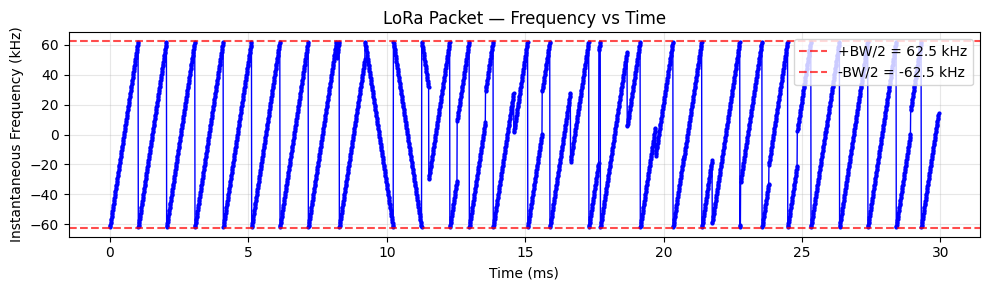

Instantaneous frequency computed for 3743 samples
Total analysed duration: 29.9 ms

LoRa transmitter — simulation complete!


In [5]:
# --- Packet length and duration analysis ---
packet_lengths = [tf.shape(packet)[0] for packet in tf.unstack(lora_packets)]
print(f"Packet lengths: {[l.numpy() for l in packet_lengths]} samples")

total_duration = packet_lengths[0].numpy() * transmitter.chip_duration.numpy()
print(f"Total packet duration: {total_duration*1000:.2f} ms")

# --- Instantaneous frequency analysis ---
print("\n" + "="*50)
print("Instantaneous frequency analysis:")

try:
    # Use the first batch sample for detailed analysis
    single_packet = lora_packets[0]
    freq_inst, time_axis = transmitter.plot_frequency_vs_time(
        single_packet, "LoRa Packet — Frequency vs Time"
    )
    print(f"Instantaneous frequency computed for {len(freq_inst)} samples")
    print(f"Total analysed duration: {time_axis[-1]:.1f} ms")

    # Uncomment to analyse a second batch element:
    # single_packet = lora_packets[1]
    # freq_inst, time_axis = transmitter.plot_frequency_vs_time(
    #     single_packet, "Packet 2 — Frequency vs Time"
    # )

except Exception as e:
    print(f"Frequency analysis error: {e}")
    import traceback
    traceback.print_exc()

print("\nLoRa transmitter — simulation complete!")


#### Computational Efficiency Analysis

**Benchmark 1** — Processing time vs batch size

**Benchmark 2** — Resource usage (CPU / RAM / GPU) vs batch size

**Benchmark 3** — Step-by-step stage profiling

CELL 1 — PROCESSING TIME BENCHMARK × BATCH SIZE
  Device detected : GPU (physical_device:GPU:0)
  Logical CPUs    : 12
  Total RAM       : 7.7 GB

TIME BENCHMARK × BATCH SIZE
  (complete pipeline — includes tf.map_fn parallelism)

  Batch size = 1 packets
  ------------------------------------------------
LoRa Transmitter configured for input shape: (1, 80)
    Total time  : 19.87 ± 3.94 ms
    Per packet  : 19.87 ms  |  Throughput: 50.3 pkt/s

  Batch size = 10 packets
  ------------------------------------------------
    Total time  : 21.68 ± 3.24 ms
    Per packet  : 2.17 ms  |  Throughput: 461.3 pkt/s

  Batch size = 50 packets
  ------------------------------------------------
    Total time  : 24.82 ± 4.30 ms
    Per packet  : 0.50 ms  |  Throughput: 2014.9 pkt/s

  Batch size = 100 packets
  ------------------------------------------------
    Total time  : 21.47 ± 1.30 ms
    Per packet  : 0.21 ms  |  Throughput: 4658.5 pkt/s

  Batch size = 200 packets
  ---------------------

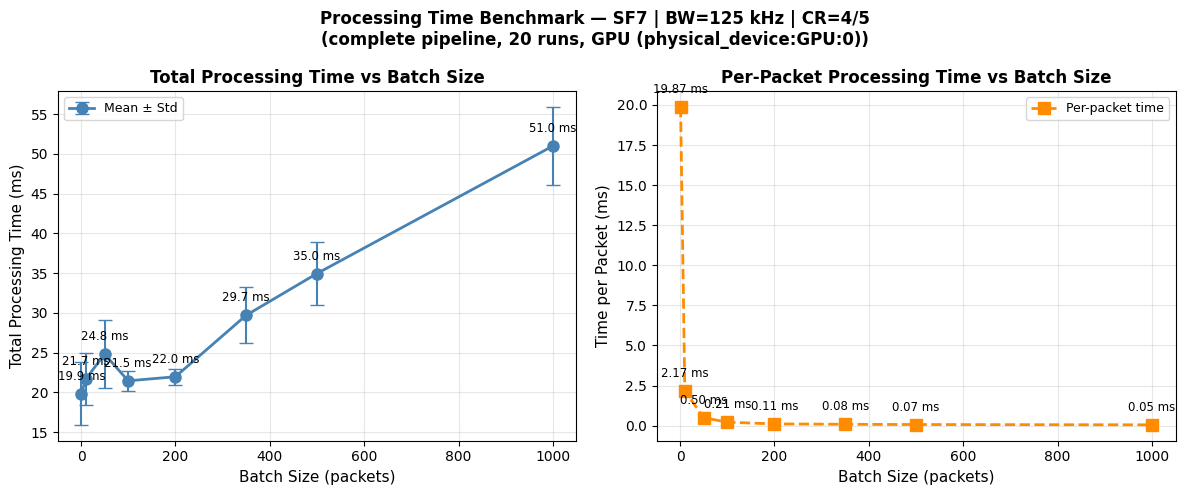

✅ Figure saved: lora_time_benchmark.png


In [6]:
# ===================================================================
# BENCHMARK 1 — PROCESSING TIME vs BATCH SIZE
# LoRa Transmitter — Sionna/TensorFlow
#
# Measures total and per-packet wall-clock time across different
# batch sizes for the complete transmit pipeline.
# ===================================================================

import time
import os
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import psutil

# ───────────────────────────────────────────────────────────────────
# HARDWARE DETECTION
# ───────────────────────────────────────────────────────────────────

_PROCESS    = psutil.Process(os.getpid())
_GPUS       = tf.config.list_physical_devices('GPU')
_HAS_GPU    = len(_GPUS) > 0
_DEVICE_STR = f"GPU ({_GPUS[0].name.split('/')[-1]})" if _HAS_GPU else "CPU only"

print("=" * 70)
print("CELL 1 — PROCESSING TIME BENCHMARK × BATCH SIZE")
print(f"  Device detected : {_DEVICE_STR}")
print(f"  Logical CPUs    : {psutil.cpu_count(logical=True)}")
print(f"  Total RAM       : {psutil.virtual_memory().total / 1024**3:.1f} GB")
print("=" * 70)

# ───────────────────────────────────────────────────────────────────
# GLOBAL PARAMETERS
# ───────────────────────────────────────────────────────────────────

NUM_RUNS   = 20   # repetitions per measurement (averaged)
NUM_WARMUP = 10    # warm-up runs (discarded)
NUM_BITS   = 80   # bits/payload (10 bytes)

LORA_CONFIG = {
    'spreading_factor': 7,
    'bandwidth': 125e3,
    'coding_rate': 1,
    'crc_on': True,
    'debug': False,
}

# BATCH_SIZES = [10, 100, 200]
BATCH_SIZES = [1, 10, 50, 100, 200, 350, 500, 1000]

# ───────────────────────────────────────────────────────────────────
# HELPER: force GPU sync (materialise tensor)
# ───────────────────────────────────────────────────────────────────

def _sync_result(result):
    """Forces GPU synchronisation by materialising the tensor."""
    if isinstance(result, tf.Tensor):
        result.numpy()
    elif isinstance(result, (list, tuple)):
        for r in result:
            if isinstance(r, tf.Tensor):
                r.numpy()
                break


# ───────────────────────────────────────────────────────────────────
# TIMING MEASUREMENT FUNCTION
# ───────────────────────────────────────────────────────────────────

def measure_time(fn, *args, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP) -> dict:
    """
    Measures execution time of a TF function.

    Parameters
    ----------
    fn         : callable — function to measure
    *args      : arguments for fn
    num_runs   : int — measurement runs (averaged)
    num_warmup : int — warm-up runs (discarded, forces JIT / @tf.function compile)

    Returns
    -------
    dict with: time_mean_ms, time_std_ms, time_min_ms, time_max_ms
    """
    # Warm-up: force JIT / @tf.function compilation
    for _ in range(num_warmup):
        r = fn(*args)
        _sync_result(r)

    # Timed runs
    times_ms = []
    for _ in range(num_runs):
        t0 = time.perf_counter()
        r = fn(*args)
        _sync_result(r)   # sync before stopping the clock
        t1 = time.perf_counter()
        times_ms.append((t1 - t0) * 1000.0)

    return {
        'time_mean_ms': float(np.mean(times_ms)),
        'time_std_ms':  float(np.std(times_ms)),
        'time_min_ms':  float(np.min(times_ms)),
        'time_max_ms':  float(np.max(times_ms)),
    }


# ───────────────────────────────────────────────────────────────────
# BENCHMARK LOOP
# ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("TIME BENCHMARK × BATCH SIZE")
print("  (complete pipeline — includes tf.map_fn parallelism)")
print("=" * 70)

tx_bench = LoRaPhyTransmitter(**LORA_CONFIG)
benchmark_records = []

for bs in BATCH_SIZES:
    print(f"\n  Batch size = {bs} packets")
    print("  " + "-" * 48)

    bits = binary_source([bs, NUM_BITS])
    m = measure_time(tx_bench, bits, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP)

    per_pkt_ms = m['time_mean_ms'] / bs
    throughput  = bs / (m['time_mean_ms'] / 1000.0)

    benchmark_records.append({
        'batch_size':   bs,
        'total_ms':     m['time_mean_ms'],
        'total_std_ms': m['time_std_ms'],
        'per_pkt_ms':   per_pkt_ms,
        'throughput':   throughput,
    })

    print(f"    Total time  : {m['time_mean_ms']:.2f} ± {m['time_std_ms']:.2f} ms")
    print(f"    Per packet  : {per_pkt_ms:.2f} ms  |  Throughput: {throughput:.1f} pkt/s")

df_bench_time = pd.DataFrame(benchmark_records)

# Tabular summary
print("\n" + "=" * 70)
print("SUMMARY — TIME BENCHMARK")
print("=" * 70)
cols = ['batch_size', 'total_ms', 'total_std_ms', 'per_pkt_ms', 'throughput']
print(df_bench_time[cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))


# ───────────────────────────────────────────────────────────────────
# PLOT — Processing Time vs Batch Size
# ───────────────────────────────────────────────────────────────────

cfg = LORA_CONFIG
bs_vals = df_bench_time['batch_size'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Total processing time ---
ax = axes[0]
ax.errorbar(
    bs_vals,
    df_bench_time['total_ms'],
    yerr=df_bench_time['total_std_ms'],
    fmt='o-', color='steelblue', linewidth=2, markersize=8,
    capsize=5, elinewidth=1.5, label='Mean ± Std'
)
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('Total Processing Time (ms)', fontsize=11)
ax.set_title('Total Processing Time vs Batch Size', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
for x, y, s in zip(bs_vals, df_bench_time['total_ms'], df_bench_time['total_std_ms']):
    ax.annotate(f'{y:.1f} ms', (x, y),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8.5)

# --- Right: Per-packet processing time ---
ax = axes[1]
ax.plot(bs_vals, df_bench_time['per_pkt_ms'], 's--', color='darkorange',
        linewidth=2, markersize=8, label='Per-packet time')
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('Time per Packet (ms)', fontsize=11)
ax.set_title('Per-Packet Processing Time vs Batch Size', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
for x, y in zip(bs_vals, df_bench_time['per_pkt_ms']):
    ax.annotate(f'{y:.2f} ms', (x, y),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8.5)

fig.suptitle(
    f"Processing Time Benchmark — SF{cfg['spreading_factor']} | "
    f"BW={int(cfg['bandwidth']/1e3)} kHz | CR=4/{4+cfg['coding_rate']}\n"
    f"(complete pipeline, {NUM_RUNS} runs, {_DEVICE_STR})",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lora_time_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: lora_time_benchmark.png")

df_bench_time.to_csv('sionna_time_benchmark.csv', index=False)

**Benchmark 2** — Resource usage (CPU / RAM / GPU) vs batch size

CELL 2 — RESOURCE USAGE BENCHMARK × BATCH SIZE
  Device detected : GPU (physical_device:GPU:0)
  Logical CPUs    : 12
  Total RAM       : 7.7 GB

RESOURCE USAGE BENCHMARK × BATCH SIZE
  (complete pipeline — includes tf.map_fn parallelism)

  Batch size = 1 packets
  ------------------------------------------------
LoRa Transmitter configured for input shape: (1, 80)
    CPU     : mean=71.0%  peak=147.9%
    (>100% = multiple cores used by TF in parallel)
    RAM     : mean=1104 MB  peak=1104 MB
    GPU mem : mean=0.1 MB  peak=0.2 MB

  Batch size = 10 packets
  ------------------------------------------------
    CPU     : mean=73.5%  peak=147.9%
    (>100% = multiple cores used by TF in parallel)
    RAM     : mean=1088 MB  peak=1088 MB
    GPU mem : mean=0.5 MB  peak=0.9 MB

  Batch size = 50 packets
  ------------------------------------------------
    CPU     : mean=102.6%  peak=147.4%
    (>100% = multiple cores used by TF in parallel)
    RAM     : mean=1101 MB  peak=1101 MB
   

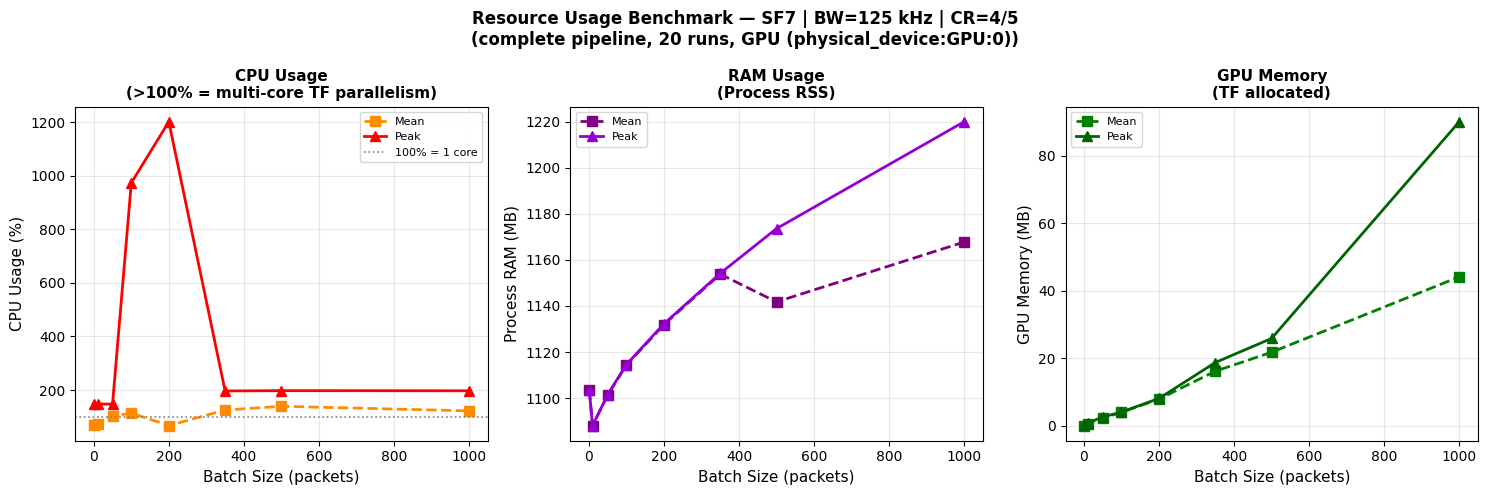

✅ Figure saved: lora_resource_benchmark.png


In [7]:
# ===================================================================
# BENCHMARK 2 — RESOURCE USAGE vs BATCH SIZE
# LoRa Transmitter — Sionna/TensorFlow
#
# NOTE on resource monitoring in parallel batches:
# ─────────────────────────────────────────────────────
# The `call` method uses `tf.map_fn(..., parallel_iterations=batch_size)`,
# which distributes packet processing across internal TF threads.
# This has two direct effects:
#
#   1. CPU: psutil measures the entire Python process. Since TF uses
#      multiple internal C++ threads (Eigen, BLAS, CUDA streams),
#      CPU% can exceed 100% (represents the sum of all cores).
#      This is expected and correct — it shows real parallelism.
#
#   2. GPU: tf.config.experimental.get_memory_info() only captures
#      allocations within the Python/TF context. Async GPU operations
#      may have already been freed when we read the peak. Therefore
#      we sample DURING and AFTER execution.
#
#   3. RAM: psutil measures RSS (Resident Set Size) of the process,
#      which includes the Python interpreter, TF runtime, and all
#      allocated tensors. It is the most reliable resource metric here.
# ===================================================================

import time
import os
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import psutil

# ───────────────────────────────────────────────────────────────────
# HARDWARE DETECTION
# ───────────────────────────────────────────────────────────────────

_PROCESS    = psutil.Process(os.getpid())
_GPUS       = tf.config.list_physical_devices('GPU')
_HAS_GPU    = len(_GPUS) > 0
_DEVICE_STR = f"GPU ({_GPUS[0].name.split('/')[-1]})" if _HAS_GPU else "CPU only"

print("=" * 70)
print("CELL 2 — RESOURCE USAGE BENCHMARK × BATCH SIZE")
print(f"  Device detected : {_DEVICE_STR}")
print(f"  Logical CPUs    : {psutil.cpu_count(logical=True)}")
print(f"  Total RAM       : {psutil.virtual_memory().total / 1024**3:.1f} GB")
print("=" * 70)

# ───────────────────────────────────────────────────────────────────
# GLOBAL PARAMETERS
# ───────────────────────────────────────────────────────────────────

NUM_RUNS   = 20
NUM_WARMUP = 10
NUM_BITS   = 80

LORA_CONFIG = {
    'spreading_factor': 7,
    'bandwidth': 125e3,
    'coding_rate': 1,
    'crc_on': True,
    'debug': False,
}

# BATCH_SIZES = [10, 100, 200]
BATCH_SIZES = [1, 10, 50, 100, 200, 350, 500, 1000]


# ───────────────────────────────────────────────────────────────────
# CONTINUOUS RESOURCE MONITOR (separate thread)
# ───────────────────────────────────────────────────────────────────

class ResourceMonitor:
    """
    Samples CPU%, RAM and GPU memory in a separate thread
    while the target function runs.

    Usage:
        mon = ResourceMonitor(interval_s=0.02)
        mon.start()
        ... run target function ...
        mon.stop()
        stats = mon.stats()   # dict with means and peaks
    """

    def __init__(self, interval_s: float = 0.02):
        self.interval_s    = interval_s
        self._cpu_samples  : list[float] = []
        self._ram_samples  : list[float] = []   # MB
        self._gpu_samples  : list[float] = []   # MB
        self._stop_event   = threading.Event()
        self._thread       = threading.Thread(target=self._run, daemon=True)

    def start(self):
        self._stop_event.clear()
        self._cpu_samples.clear()
        self._ram_samples.clear()
        self._gpu_samples.clear()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop_event.set()
        self._thread.join(timeout=2.0)

    def _run(self):
        # Prime psutil CPU counter (first call returns 0.0 by design)
        _PROCESS.cpu_percent(interval=None)
        while not self._stop_event.is_set():
            # cpu_percent(interval=None) returns utilisation since last call.
            # We store the raw per-process value; >100% is expected on
            # multi-core machines when TF uses multiple threads.
            self._cpu_samples.append(
                _PROCESS.cpu_percent(interval=None)
            )
            # RSS: bytes → MB
            self._ram_samples.append(
                _PROCESS.memory_info().rss / 1024**2
            )
            if _HAS_GPU:
                try:
                    info = tf.config.experimental.get_memory_info('GPU:0')
                    self._gpu_samples.append(info['current'] / 1024**2)
                except Exception:
                    pass
            time.sleep(self.interval_s)

    def stats(self) -> dict:
        """Returns statistics from collected samples."""
        def _s(lst):
            if not lst:
                return {'mean': 0.0, 'peak': 0.0, 'std': 0.0}
            a = np.array(lst, dtype=float)
            # Drop the first sample (CPU counter priming artifact)
            if len(a) > 1:
                a = a[1:]
            return {'mean': float(a.mean()), 'peak': float(a.max()), 'std': float(a.std())}

        return {
            'cpu':      _s(self._cpu_samples),   # % (can exceed 100% on multi-core)
            'ram':      _s(self._ram_samples),   # MB
            'gpu':      _s(self._gpu_samples),   # MB (empty if no GPU)
            'n_samples': len(self._cpu_samples),
        }


# ───────────────────────────────────────────────────────────────────
# RESOURCE MEASUREMENT FUNCTION
# ───────────────────────────────────────────────────────────────────

def _sync_result(result):
    """Forces GPU synchronisation by materialising the tensor."""
    if isinstance(result, tf.Tensor):
        result.numpy()
    elif isinstance(result, (list, tuple)):
        for r in result:
            if isinstance(r, tf.Tensor):
                r.numpy()
                break


def measure_resources(fn, *args,
                      num_runs=NUM_RUNS,
                      num_warmup=NUM_WARMUP,
                      monitor_interval=0.02) -> dict:
    """
    Measures CPU / RAM / GPU usage of a TF function.

    Parameters
    ----------
    fn               : callable — function to measure
    *args            : arguments for fn
    num_runs         : int — measurement runs (averaged)
    num_warmup       : int — warm-up runs (forces JIT / @tf.function compile)
    monitor_interval : float — resource sampling interval in seconds

    Returns
    -------
    dict with:
      cpu_mean_pct, cpu_peak_pct
      ram_mean_mb,  ram_peak_mb
      gpu_mean_mb,  gpu_peak_mb  (0.0 if no GPU)
    """
    # Warm-up
    for _ in range(num_warmup):
        r = fn(*args)
        _sync_result(r)

    monitor = ResourceMonitor(interval_s=monitor_interval)
    all_stats = []

    for _ in range(num_runs):
        if _HAS_GPU:
            try:
                tf.config.experimental.reset_memory_stats('GPU:0')
            except Exception:
                pass

        monitor.start()
        r = fn(*args)
        _sync_result(r)          # sync before stopping monitor
        monitor.stop()

        all_stats.append(monitor.stats())

    # Aggregate resource statistics across runs
    cpu_means = [s['cpu']['mean'] for s in all_stats]
    cpu_peaks = [s['cpu']['peak'] for s in all_stats]
    ram_means = [s['ram']['mean'] for s in all_stats]
    ram_peaks = [s['ram']['peak'] for s in all_stats]
    gpu_means = [s['gpu']['mean'] for s in all_stats if s['gpu']['mean'] > 0]
    gpu_peaks = [s['gpu']['peak'] for s in all_stats if s['gpu']['peak'] > 0]

    return {
        'cpu_mean_pct': float(np.mean(cpu_means)) if cpu_means else 0.0,
        'cpu_peak_pct': float(np.max(cpu_peaks))  if cpu_peaks else 0.0,
        'ram_mean_mb':  float(np.mean(ram_means)) if ram_means else 0.0,
        'ram_peak_mb':  float(np.max(ram_peaks))  if ram_peaks else 0.0,
        'gpu_mean_mb':  float(np.mean(gpu_means)) if gpu_means else 0.0,
        'gpu_peak_mb':  float(np.max(gpu_peaks))  if gpu_peaks else 0.0,
    }


# ───────────────────────────────────────────────────────────────────
# BENCHMARK LOOP
# ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("RESOURCE USAGE BENCHMARK × BATCH SIZE")
print("  (complete pipeline — includes tf.map_fn parallelism)")
print("=" * 70)

tx_bench = LoRaPhyTransmitter(**LORA_CONFIG)
benchmark_records = []

for bs in BATCH_SIZES:
    print(f"\n  Batch size = {bs} packets")
    print("  " + "-" * 48)

    bits = binary_source([bs, NUM_BITS])
    m = measure_resources(tx_bench, bits, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP)

    benchmark_records.append({
        'batch_size':   bs,
        'cpu_mean_pct': m['cpu_mean_pct'],
        'cpu_peak_pct': m['cpu_peak_pct'],
        'ram_mean_mb':  m['ram_mean_mb'],
        'ram_peak_mb':  m['ram_peak_mb'],
        'gpu_mean_mb':  m['gpu_mean_mb'],
        'gpu_peak_mb':  m['gpu_peak_mb'],
    })

    print(f"    CPU     : mean={m['cpu_mean_pct']:.1f}%  peak={m['cpu_peak_pct']:.1f}%")
    print(f"    (>100% = multiple cores used by TF in parallel)")
    print(f"    RAM     : mean={m['ram_mean_mb']:.0f} MB  peak={m['ram_peak_mb']:.0f} MB")
    if _HAS_GPU:
        print(f"    GPU mem : mean={m['gpu_mean_mb']:.1f} MB  peak={m['gpu_peak_mb']:.1f} MB")

df_bench_res = pd.DataFrame(benchmark_records)

# Tabular summary
print("\n" + "=" * 70)
print("SUMMARY — RESOURCE BENCHMARK")
print("=" * 70)
cols = ['batch_size', 'cpu_mean_pct', 'cpu_peak_pct',
        'ram_mean_mb', 'ram_peak_mb', 'gpu_mean_mb', 'gpu_peak_mb']
print(df_bench_res[cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))


# ───────────────────────────────────────────────────────────────────
# PLOT — Resource Usage vs Batch Size
# ───────────────────────────────────────────────────────────────────

cfg = LORA_CONFIG
bs_vals = df_bench_res['batch_size'].values

# n_cols = 3 if not _HAS_GPU else 4
n_cols = 2 if not _HAS_GPU else 3
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

# --- CPU ---
ax = axes[0]
ax.plot(bs_vals, df_bench_res['cpu_mean_pct'], 's--', color='darkorange',
        linewidth=2, markersize=7, label='Mean')
ax.plot(bs_vals, df_bench_res['cpu_peak_pct'], '^-', color='red',
        linewidth=2, markersize=7, label='Peak')
ax.axhline(100, color='gray', linestyle=':', linewidth=1.2,
           label='100% = 1 core')
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('CPU Usage (%)', fontsize=11)
ax.set_title('CPU Usage\n(>100% = multi-core TF parallelism)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- RAM ---
ax = axes[1]
ax.plot(bs_vals, df_bench_res['ram_mean_mb'], 's--', color='purple',
        linewidth=2, markersize=7, label='Mean')
ax.plot(bs_vals, df_bench_res['ram_peak_mb'], '^-', color='darkviolet',
        linewidth=2, markersize=7, label='Peak')
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('Process RAM (MB)', fontsize=11)
ax.set_title('RAM Usage\n(Process RSS)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- GPU (only if available) ---
if _HAS_GPU:
    ax = axes[2]
    ax.plot(bs_vals, df_bench_res['gpu_mean_mb'], 's--', color='green',
            linewidth=2, markersize=7, label='Mean')
    ax.plot(bs_vals, df_bench_res['gpu_peak_mb'], '^-', color='darkgreen',
            linewidth=2, markersize=7, label='Peak')
    ax.set_xlabel('Batch Size (packets)', fontsize=11)
    ax.set_ylabel('GPU Memory (MB)', fontsize=11)
    ax.set_title('GPU Memory\n(TF allocated)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
#     ax_notes = axes[3]
# else:
#     ax_notes = axes[2]

# --- Annotation panel: measurement notes ---
# ax_notes.axis('off')
# notes = (
#     "Measurement notes\n"
#     "─────────────────\n\n"
#     "CPU (%):\n"
#     "  psutil measures the entire Python\n"
#     "  process. TF uses multiple C++ threads\n"
#     "  (Eigen/BLAS), so >100% is expected\n"
#     "  and reflects real multi-core parallelism.\n\n"
#     "RAM (MB):\n"
#     "  RSS (Resident Set Size) of the process.\n"
#     "  Includes Python interpreter, TF runtime\n"
#     "  and all allocated tensors.\n\n"
#     "GPU (MB):\n"
#     "  tf.config.experimental.get_memory_info\n"
#     "  captures current TF allocations.\n"
#     "  Async ops may show lower peaks than\n"
#     "  actual GPU usage."
# )
# ax_notes.text(0.02, 0.98, notes,
#               transform=ax_notes.transAxes,
#               fontsize=8.5, verticalalignment='top',
#               fontfamily='monospace',
#               bbox=dict(boxstyle='round', facecolor='lightyellow',
#                         edgecolor='gray', alpha=0.7))

fig.suptitle(
    f"Resource Usage Benchmark — SF{cfg['spreading_factor']} | "
    f"BW={int(cfg['bandwidth']/1e3)} kHz | CR=4/{4+cfg['coding_rate']}\n"
    f"(complete pipeline, {NUM_RUNS} runs, {_DEVICE_STR})",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lora_resource_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: lora_resource_benchmark.png")

df_bench_res.to_csv('sionna_resource_benchmark.csv', index=False)

**Benchmark 3** — Step-by-step stage profiling

STEP-BY-STEP PROFILING — LoRaPhyTransmitter (batch-parallel)
  Device detected : GPU (physical_device:GPU:0)

  Configuring transmitter (SF=7, BW=125 kHz, CR=4/5)...
  Transmissor criado
  Bits por payload : 80 (10 bytes)
  Batch size (modo B) : 100
  Runs/stage : 20 medições + 10 warm-up

MODE A — batch = 1  (sequential / no-batch baseline)

  > 0a. Preâmbulo (_compute_preamble — init only)
    3.610 ± 2.195 ms

  > 0b. Sync Word (_compute_sync_word — init only)
    2.563 ± 2.186 ms

  > 0c. Down-Chirps (_compute_down_chirps — init only)
    4.394 ± 1.553 ms

  > 1. Whitening
    1.958 ± 0.721 ms

  > 2. Header (generate_header_batch)
    2.672 ± 0.820 ms

  > 3. CRC (add_lora_crc_batch)
    2.724 ± 0.870 ms

  > 4. Hamming Encode (hamming_encode_batch)
    7.111 ± 1.395 ms

  > 5. Interleaving (interleaving_batch)
    2.628 ± 0.792 ms

  > 6. Gray + Chirp Mod (encode_data_batch)
    4.290 ± 1.423 ms

  > 7. call() completo (pipeline end-to-end)
LoRa Transmitter configured for input s

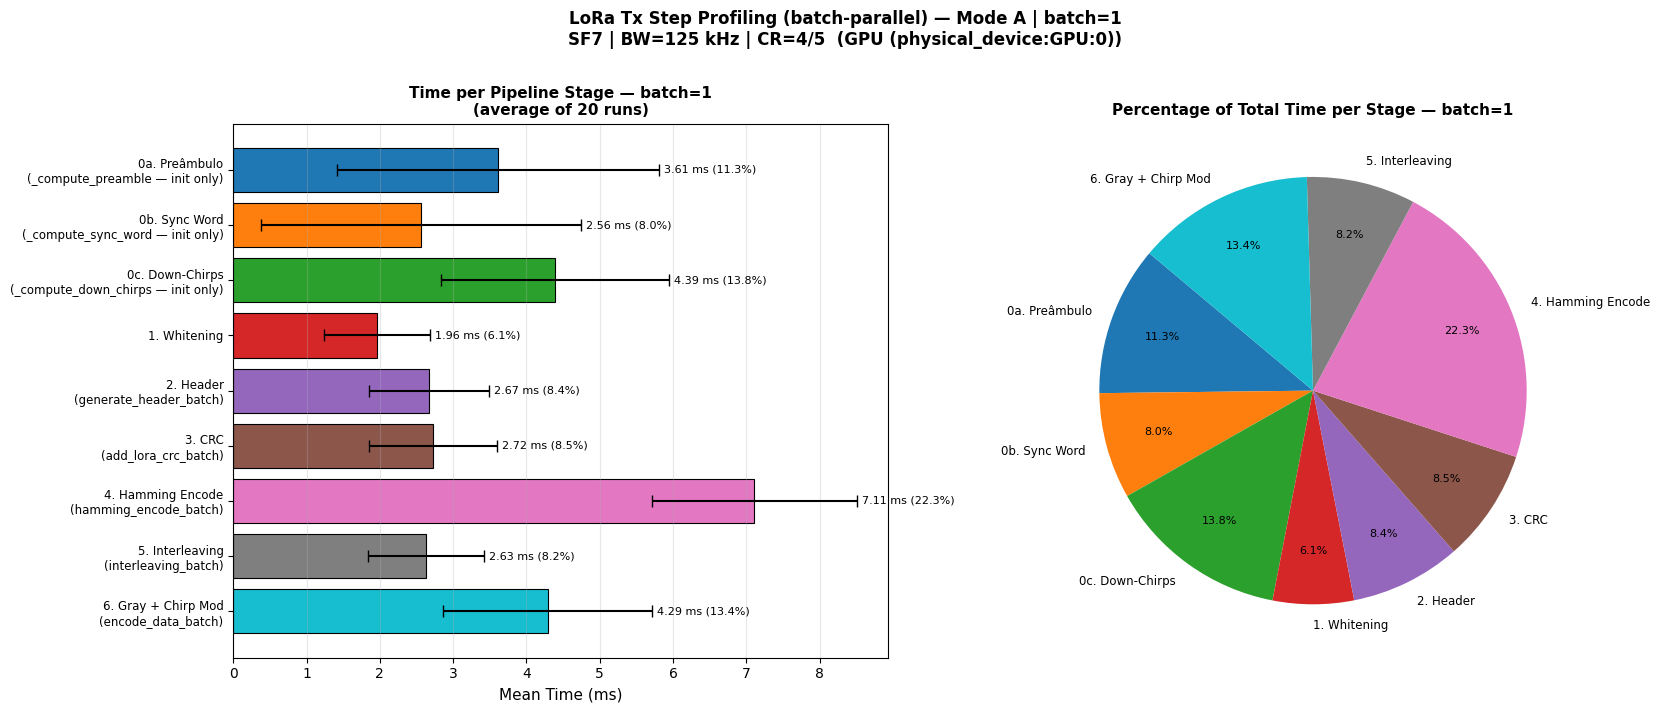

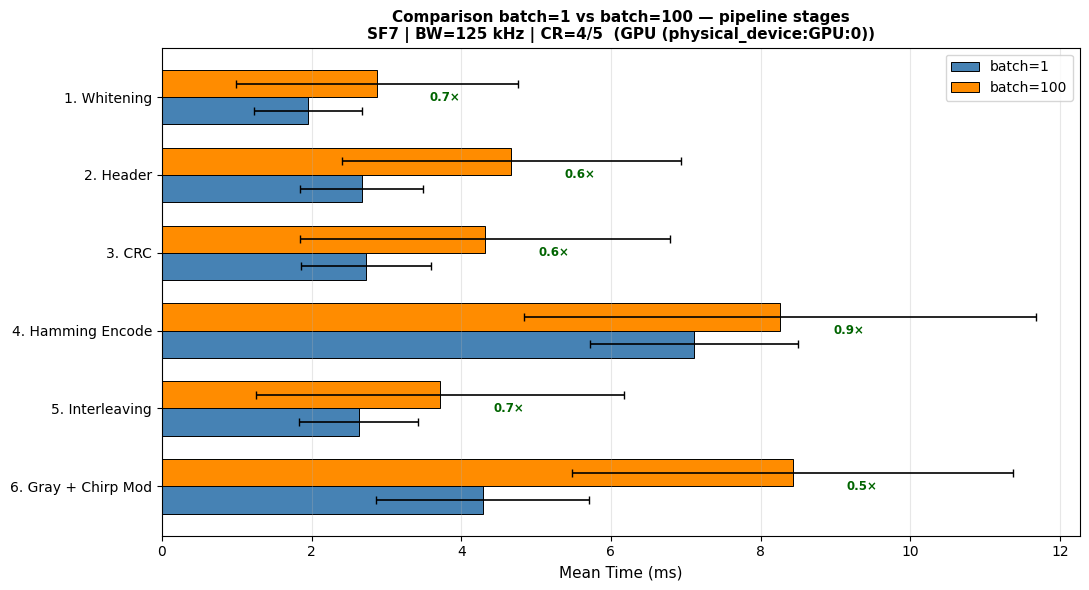


✅ Figures saved:
   lora_profiling_batch1.png
   lora_profiling_batch_comparison.png

✅ Profiling completo!


In [8]:
# ===================================================================
# BENCHMARK 3 — STEP-BY-STEP STAGE PROFILING
# LoRaPhyTransmitter — batch-parallel version
#
# Profiles each pipeline stage individually:
#   - All stage functions receive [B, N] (explicit batch dimension)
#   - Preamble / sync / down-chirps are pre-computed in __init__ and are
#     not runtime pipeline stages; measured separately as init-cost reference.
#   - Current stage methods:
#       whitening              [B,N]     → [B,N]
#       generate_header_batch  [B]       → [B,20]
#       add_lora_crc_batch     [B,N]     → [B,16]
#       hamming_encode_batch   [B,N]     → [B,N_coded]
#       interleaving_batch     [B,N]     → [B,N_sym]
#       encode_data_batch      [B,N_sym] → [B,N_sym,n_chips]
#
# Two measurement modes:
#   A) batch=1         — comparable to sequential baseline
#   B) batch=BATCH_SIZE — shows real GPU parallelism gain
# ===================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ───────────────────────────────────────────────────────────────────
# HARDWARE DETECTION
# ───────────────────────────────────────────────────────────────────

_GPUS       = tf.config.list_physical_devices('GPU')
_HAS_GPU    = len(_GPUS) > 0
_DEVICE_STR = (f"GPU ({_GPUS[0].name.split('/')[-1]})"
               if _HAS_GPU else "CPU only")

print("=" * 70)
print("STEP-BY-STEP PROFILING — LoRaPhyTransmitter (batch-parallel)")
print(f"  Device detected : {_DEVICE_STR}")
print("=" * 70)

# ───────────────────────────────────────────────────────────────────
# GLOBAL PARAMETERS
# ───────────────────────────────────────────────────────────────────

NUM_RUNS   = 20
NUM_WARMUP = 10
NUM_BITS   = 80        # bits/payload  (10 bytes)
BATCH_SIZE = 100        # batch size para o modo B

LORA_CONFIG = {
    'spreading_factor': 7,
    'bandwidth': 125e3,
    'coding_rate': 1,
    'crc_on': True,
    'debug': False,
}

# ───────────────────────────────────────────────────────────────────
# HELPERS
# ───────────────────────────────────────────────────────────────────

def _sync_result(result):
    """Force GPU synchronisation by materialising the tensor."""
    if isinstance(result, tf.Tensor):
        result.numpy()
    elif isinstance(result, (list, tuple)):
        for r in result:
            if isinstance(r, tf.Tensor):
                r.numpy()
                break


def measure_step(fn, *args, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP) -> dict:
    """
    Measure mean execution time of an isolated pipeline stage.

    Parameters
    ----------
    fn         : callable  — stage function to measure
    *args      : arguments for fn
    num_runs   : int  — repetitions for averaging
    num_warmup : int  — warm-up runs (discarded; forces @tf.function compilation)

    Returns
    -------
    dict: mean_ms, std_ms, min_ms, max_ms
    """
    for _ in range(num_warmup):
        _sync_result(fn(*args))

    times_ms = []
    for _ in range(num_runs):
        t0 = time.perf_counter()
        r  = fn(*args)
        _sync_result(r)
        times_ms.append((time.perf_counter() - t0) * 1000.0)

    return {
        'mean_ms': float(np.mean(times_ms)),
        'std_ms':  float(np.std(times_ms)),
        'min_ms':  float(np.min(times_ms)),
        'max_ms':  float(np.max(times_ms)),
    }


def _measure(records, name, fn, *args):
    print(f"\n  > {name.replace(chr(10), ' ')}")
    m = measure_step(fn, *args)
    print(f"    {m['mean_ms']:.3f} ± {m['std_ms']:.3f} ms")
    records.append({'stage': name, **m})
    return m


# ───────────────────────────────────────────────────────────────────
# SETUP
# ───────────────────────────────────────────────────────────────────

cfg = LORA_CONFIG
print(f"\n  Configuring transmitter "
      f"(SF={cfg['spreading_factor']}, "
      f"BW={int(cfg['bandwidth']/1e3)} kHz, "
      f"CR=4/{4+cfg['coding_rate']})...")

tx = LoRaPhyTransmitter(**LORA_CONFIG)

# Payloads: [1, N] for mode A  |  [B, N] for mode B
bits_b1 = tf.cast(binary_source([1, NUM_BITS]),         tf.int32)  # [1,  N]
bits_bN = tf.cast(binary_source([BATCH_SIZE, NUM_BITS]), tf.int32)  # [B,  N]

print(f"  Transmissor criado")
print(f"  Bits por payload : {NUM_BITS} ({NUM_BITS // 8} bytes)")
print(f"  Batch size (modo B) : {BATCH_SIZE}")
print(f"  Runs/stage : {NUM_RUNS} medições + {NUM_WARMUP} warm-up")


# ═══════════════════════════════════════════════════════════════════
# MODE A — batch = 1  (sequential baseline)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print(f"MODE A — batch = 1  (sequential / no-batch baseline)")
print("=" * 70)

records_a = []

# ── Init-time costs (pre-computed in __init__) ────────────────────
# Preamble/sync/down-chirps are TF constants built once in __init__.
# Re-creating them here serves as an init-cost reference only;
# these computations do NOT occur during call().
_measure(records_a,
         "0a. Preâmbulo\n(_compute_preamble — init only)",
         tx._compute_preamble)

_measure(records_a,
         "0b. Sync Word\n(_compute_sync_word — init only)",
         tx._compute_sync_word)

_measure(records_a,
         "0c. Down-Chirps\n(_compute_down_chirps — init only)",
         tx._compute_down_chirps)

# ── Pipeline stages (executed in call()) ──────────────────────────

# 1. Whitening  [1, N] → [1, N]
_measure(records_a, "1. Whitening", tx.whitening, bits_b1)

whitened_a = tx.whitening(bits_b1)                                 # [1, N]
lengths_a  = tf.constant([NUM_BITS], dtype=tf.int32)               # [1]

# 2. Header  [1] → [1, 20]
_measure(records_a,
         "2. Header\n(generate_header_batch)",
         tx.generate_header_batch, lengths_a)

headers_a = tx.generate_header_batch(lengths_a)                    # [1, 20]

# 3. CRC  [1, N] → [1, 16]
_measure(records_a,
         "3. CRC\n(add_lora_crc_batch)",
         tx.add_lora_crc_batch, bits_b1)

crc_a = tx.add_lora_crc_batch(bits_b1)                             # [1, 16]

# Frame: header + whitened_payload + crc  → [1, 20+N+16]
frame_a = tf.concat([headers_a, whitened_a, crc_a], axis=1)

# 4. Hamming  [1, 20+N+16] → [1, N_coded]
_measure(records_a,
         "4. Hamming Encode\n(hamming_encode_batch)",
         tx.hamming_encode_batch, frame_a)

coded_a = tx.hamming_encode_batch(frame_a)                         # [1, N_coded]

# 5. Interleaving  [1, N_coded] → [1, N_sym]
_measure(records_a,
         "5. Interleaving\n(interleaving_batch)",
         tx.interleaving_batch, coded_a)

symbols_a = tx.interleaving_batch(coded_a)                         # [1, N_sym]

# 6. Gray + Chirp Modulation  [1, N_sym] → [1, N_sym, n_chips]
_measure(records_a,
         "6. Gray + Chirp Mod\n(encode_data_batch)",
         tx.encode_data_batch, symbols_a)

# 7. call() completo — inclui montagem do pacote e broadcast do batch
_measure(records_a,
         "7. call() completo\n(pipeline end-to-end)",
         tx, bits_b1)


# ═══════════════════════════════════════════════════════════════════
# MODE B — batch = BATCH_SIZE  (GPU parallelism gain)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print(f"MODO B — batch = {BATCH_SIZE}  (paralelismo batch)")
print("=" * 70)

records_b = []

_measure(records_b, "1. Whitening", tx.whitening, bits_bN)

whitened_b = tx.whitening(bits_bN)
lengths_b  = tf.fill([BATCH_SIZE], NUM_BITS)

_measure(records_b,
         "2. Header\n(generate_header_batch)",
         tx.generate_header_batch, lengths_b)

headers_b = tx.generate_header_batch(lengths_b)
crc_b     = tx.add_lora_crc_batch(bits_bN)

_measure(records_b,
         "3. CRC\n(add_lora_crc_batch)",
         tx.add_lora_crc_batch, bits_bN)

frame_b = tf.concat([headers_b, whitened_b, crc_b], axis=1)

_measure(records_b,
         "4. Hamming Encode\n(hamming_encode_batch)",
         tx.hamming_encode_batch, frame_b)

coded_b = tx.hamming_encode_batch(frame_b)

_measure(records_b,
         "5. Interleaving\n(interleaving_batch)",
         tx.interleaving_batch, coded_b)

symbols_b = tx.interleaving_batch(coded_b)

_measure(records_b,
         "6. Gray + Chirp Mod\n(encode_data_batch)",
         tx.encode_data_batch, symbols_b)

_measure(records_b,
         f"7. call() completo\n(pipeline end-to-end, B={BATCH_SIZE})",
         tx, bits_bN)


# ═══════════════════════════════════════════════════════════════════
# SUMMARY TABLES
# ═══════════════════════════════════════════════════════════════════

def _print_table(records, title):
    df = pd.DataFrame(records)
    total = df['mean_ms'].sum()
    df['pct'] = (df['mean_ms'] / total * 100).round(1)
    print(f"\n{'='*70}")
    print(f"SUMMARY — {title}")
    print(f"{'='*70}")
    hdr = f"{'Stage':<48} {'Média(ms)':>10} {'Std(ms)':>9} {'%':>7}"
    print(hdr)
    print("-" * len(hdr))
    for _, row in df.iterrows():
        name = row['stage'].replace('\n', ' ')
        print(f"{name:<48} {row['mean_ms']:>10.3f} {row['std_ms']:>9.3f} "
              f"{row['pct']:>6.1f}%")
    print("-" * len(hdr))
    print(f"{'TOTAL (sum of stages)':<48} {total:>10.3f}")
    return df

df_a = _print_table(records_a, f"MODE A — batch=1")
df_b = _print_table(records_b, f"MODE B — batch={BATCH_SIZE}")

# Parallelism efficiency (common stages, excluding init-only and call())
pipeline_stages = ["1. Whitening",
                   "2. Header\n(generate_header_batch)",
                   "3. CRC\n(add_lora_crc_batch)",
                   "4. Hamming Encode\n(hamming_encode_batch)",
                   "5. Interleaving\n(interleaving_batch)",
                   "6. Gray + Chirp Mod\n(encode_data_batch)"]

total_a = df_a[df_a['stage'].isin(pipeline_stages)]['mean_ms'].sum()
total_b = df_b[df_b['stage'].isin(pipeline_stages)]['mean_ms'].sum()

print(f"\n  Tempo pipeline (stages 1-6):")
print(f"    batch=1          : {total_a:.3f} ms")
print(f"    batch={BATCH_SIZE:<3}        : {total_b:.3f} ms")
if total_b > 0:
    speedup = total_a / total_b
    efficiency = speedup / BATCH_SIZE * 100
    print(f"    Speedup          : {speedup:.2f}×")
    print(f"    GPU efficiency   : {efficiency:.1f}%  (ideal=100%)")


# ═══════════════════════════════════════════════════════════════════
# FIGURES
# ═══════════════════════════════════════════════════════════════════

COLORS = plt.cm.tab10(np.linspace(0, 0.9, max(len(df_a), len(df_b))))

# ── Figure 1: Mode A — bar + pie (pipeline stages only, no call()) ──
# Exclude the end-to-end call() entry so only individual stages are shown
df_a_steps = df_a[df_a['stage'].isin(pipeline_stages +
    [s for s in df_a['stage'] if s.startswith('0')])].copy()
# Recompute percentages relative to the filtered subset
df_a_steps['pct'] = (df_a_steps['mean_ms'] / df_a_steps['mean_ms'].sum() * 100).round(1)

fig1, axes1 = plt.subplots(1, 2, figsize=(17, 7))

labels_a_full  = df_a_steps['stage'].tolist()
labels_a_short = [s.split('\n')[0] for s in labels_a_full]
means_a  = df_a_steps['mean_ms'].values
stds_a   = df_a_steps['std_ms'].values
pcts_a   = df_a_steps['pct'].values
colors_a = plt.cm.tab10(np.linspace(0, 0.9, len(df_a_steps)))

ax = axes1[0]
bars = ax.barh(range(len(means_a)), means_a,
               xerr=stds_a, color=colors_a, edgecolor='black', linewidth=0.8,
               error_kw={'elinewidth': 1.5, 'capsize': 4})
ax.set_yticks(range(len(labels_a_full)))
ax.set_yticklabels(labels_a_full, fontsize=8.5)
ax.set_xlabel('Mean Time (ms)', fontsize=11)
ax.set_title(f'Time per Pipeline Stage — batch=1\n(average of {NUM_RUNS} runs)',
             fontsize=11, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()
for bar, val, std, pct in zip(bars, means_a, stds_a, pcts_a):
    ax.text(bar.get_width() + std + max(means_a) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f} ms ({pct}%)', va='center', fontsize=8)

ax2 = axes1[1]
wedges, texts, autotexts = ax2.pie(
    means_a, labels=labels_a_short,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=colors_a, startangle=140, pctdistance=0.75,
    textprops={'fontsize': 8.5}
)
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('Percentage of Total Time per Stage — batch=1',
              fontsize=11, fontweight='bold')

fig1.suptitle(
    f"LoRa Tx Step Profiling (batch-parallel) — Mode A | batch=1\n"
    f"SF{cfg['spreading_factor']} | BW={int(cfg['bandwidth']/1e3)} kHz | "
    f"CR=4/{4+cfg['coding_rate']}  ({_DEVICE_STR})",
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('lora_profiling_batch1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: comparison batch=1 vs batch=B (stages 1-6) ───────────
df_a_pipe = df_a[df_a['stage'].isin(pipeline_stages)].copy()
df_b_pipe = df_b[df_b['stage'].isin(pipeline_stages)].copy()

fig2, ax = plt.subplots(figsize=(11, 6))
y      = np.arange(len(pipeline_stages))
height = 0.35

bars_a = ax.barh(y + height/2, df_a_pipe['mean_ms'].values,
                 height, xerr=df_a_pipe['std_ms'].values,
                 label='batch=1', color='steelblue', edgecolor='black',
                 linewidth=0.7, error_kw={'elinewidth': 1.2, 'capsize': 3})
bars_b = ax.barh(y - height/2, df_b_pipe['mean_ms'].values,
                 height, xerr=df_b_pipe['std_ms'].values,
                 label=f'batch={BATCH_SIZE}', color='darkorange', edgecolor='black',
                 linewidth=0.7, error_kw={'elinewidth': 1.2, 'capsize': 3})

ax.set_yticks(y)
ax.set_yticklabels([s.split('\n')[0] for s in pipeline_stages], fontsize=10)
ax.set_xlabel('Mean Time (ms)', fontsize=11)
ax.set_title(
    f'Comparison batch=1 vs batch={BATCH_SIZE} — pipeline stages\n'
    f'SF{cfg["spreading_factor"]} | BW={int(cfg["bandwidth"]/1e3)} kHz | '
    f'CR=4/{4+cfg["coding_rate"]}  ({_DEVICE_STR})',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

# Annotate per-stage speedup
for i, (va, vb) in enumerate(zip(df_a_pipe['mean_ms'].values,
                                  df_b_pipe['mean_ms'].values)):
    sp = va / vb if vb > 0 else float('inf')
    x_pos = max(va, vb) + max(df_a_pipe['std_ms'].values) * 0.5
    ax.text(x_pos, y[i], f'{sp:.1f}×', va='center', fontsize=8.5,
            color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('lora_profiling_batch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figures saved:")
print("   lora_profiling_batch1.png")
print("   lora_profiling_batch_comparison.png")
print("\n" + "=" * 70)
print("✅ Profiling completo!")
print("=" * 70)

df_a_steps.to_csv('sionna_step_profiling.csv', index=False)